# Logistic Regression: Predicting Bot-Like Spotify Accounts

**Research Question (RQ1):**  
Among Spotify users, which behavioral features — specifically skip rate, listening diversity, listening time, and genre preference — significantly predict the likelihood that an account exhibits bot-like behavior?

**Hypotheses:**
- **H1a:** Higher skip rates are positively associated with the probability of bot-like classification (OR > 1, p < .05).
- **H1b:** Lower listening diversity scores are positively associated with the probability of bot-like classification (OR < 1, p < .05).

This notebook covers:
1. Data preparation and dummy coding
2. Full logistic regression model
3. Odds ratios with 95% confidence intervals
4. Model diagnostics (multicollinearity, classification report, ROC curve)
5. Model selection via AIC/BIC (comparing 2–3 candidate models)

## 1. Setup

In [ ]:
import sys
import os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

from src.data_loader import load_and_clean_data, create_dummies

%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = ["#1DB954", "#B3B3B3"]

## 2. Load and Prepare Data

In [ ]:
# Load cleaned dataset
df = pd.read_csv(os.path.join("..", "data", "cleaned", "spotify_clean_v1.csv"))
print(f"Dataset: {df.shape[0]} observations, {df.shape[1]} columns")
print(f"\nBot-like distribution:\n{df['bot_like'].value_counts()}")
print(f"\nBot-like rate: {df['bot_like'].mean():.1%}")

Dataset: 520 observations, 29 columns

Bot-like distribution:
bot_like
0    442
1     78
Name: count, dtype: int64

Bot-like rate: 15.0%


In [ ]:
# Dummy-code genre (reference category = most common genre)
print("Genre distribution:")
print(df["fav_music_genre"].value_counts())

df_model = create_dummies(df, columns=["fav_music_genre"])

# Identify the genre dummy columns created
genre_dummies = [c for c in df_model.columns if c.startswith("fav_music_genre_")]
print(f"\nGenre dummies created ({len(genre_dummies)}): {genre_dummies}")

Genre distribution:
fav_music_genre
Melody              265
Pop                  91
Classical            89
Rap                  55
Electronic/Dance     16
Rock                  4
Name: count, dtype: int64

Genre dummies created (5): ['fav_music_genre_Electronic/Dance', 'fav_music_genre_Melody', 'fav_music_genre_Pop', 'fav_music_genre_Rap', 'fav_music_genre_Rock']


In [ ]:
# Define predictor sets for model comparison
core_predictors = ["skip_rate", "diversity_score", "listening_time", "age_numeric"]
full_predictors = core_predictors + genre_dummies

print("Core predictors:", core_predictors)
print("Full predictors:", full_predictors)

Core predictors: ['skip_rate', 'diversity_score', 'listening_time', 'age_numeric']
Full predictors: ['skip_rate', 'diversity_score', 'listening_time', 'age_numeric', 'fav_music_genre_Electronic/Dance', 'fav_music_genre_Melody', 'fav_music_genre_Pop', 'fav_music_genre_Rap', 'fav_music_genre_Rock']


## 3. Multicollinearity Check (VIF)

Before fitting the logistic regression, we check the Variance Inflation Factor for all predictors. VIF > 5 signals concerning multicollinearity; VIF > 10 is problematic.

In [ ]:
# VIF for full predictor set
X_vif = df_model[full_predictors].dropna()
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame({
    "Variable": X_vif.columns[1:],  # skip constant
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(1, X_vif.shape[1])
    ],
})
vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)
print("Variance Inflation Factors:")
print(vif_data.to_string(index=False))

Variance Inflation Factors:
                        Variable      VIF
          fav_music_genre_Melody 2.260553
                  listening_time 2.038959
             fav_music_genre_Pop 1.924055
                 diversity_score 1.711634
             fav_music_genre_Rap 1.453938
fav_music_genre_Electronic/Dance 1.197381
                       skip_rate 1.135891
            fav_music_genre_Rock 1.050993
                     age_numeric 1.050814


## 4. Model 1: Core Predictors Only

Logistic regression with behavioral features only (no genre dummies).

In [ ]:
# Model 1: Core behavioral predictors
y = df_model["bot_like"]
X1 = sm.add_constant(df_model[core_predictors])

model1 = sm.Logit(y, X1).fit()
print(model1.summary())

Optimization terminated successfully.
         Current function value: 0.262067
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               bot_like   No. Observations:                  520
Model:                          Logit   Df Residuals:                      515
Method:                           MLE   Df Model:                            4
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.3800
Time:                        18:18:10   Log-Likelihood:                -136.27
converged:                       True   LL-Null:                       -219.81
Covariance Type:            nonrobust   LLR p-value:                 4.454e-35
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -6.6924      1.177     -5.685      0.000      -8.999      -4.385
skip_rate     

## 5. Model 2: Full Model (Core + Genre Dummies)

Adding genre preference as a categorical predictor.

In [ ]:
# Model 2: Core + genre dummies
X2 = sm.add_constant(df_model[full_predictors])

model2 = sm.Logit(y, X2).fit()
print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.252839
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               bot_like   No. Observations:                  520
Model:                          Logit   Df Residuals:                      510
Method:                           MLE   Df Model:                            9
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.4019
Time:                        18:18:10   Log-Likelihood:                -131.48
converged:                       True   LL-Null:                       -219.81
Covariance Type:            nonrobust   LLR p-value:                 2.517e-33
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -7.2142      1.255     -5.75

## 6. Model 3: Parsimonious Model

Retain only predictors that were significant (p < .10) in Model 2, for a more parsimonious specification.

In [ ]:
# Identify significant predictors from Model 2 (p < .10)
sig_vars = model2.pvalues[model2.pvalues < 0.10].index.tolist()
sig_vars = [v for v in sig_vars if v != "const"]  # keep predictors only
print(f"Significant predictors (p < .10): {sig_vars}")

# Model 3: Parsimonious
X3 = sm.add_constant(df_model[sig_vars])
model3 = sm.Logit(y, X3).fit()
print(model3.summary())

Significant predictors (p < .10): ['skip_rate', 'diversity_score', 'listening_time', 'fav_music_genre_Electronic/Dance']
Optimization terminated successfully.
         Current function value: 0.258137
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               bot_like   No. Observations:                  520
Model:                          Logit   Df Residuals:                      515
Method:                           MLE   Df Model:                            4
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.3893
Time:                        18:18:10   Log-Likelihood:                -134.23
converged:                       True   LL-Null:                       -219.81
Covariance Type:            nonrobust   LLR p-value:                 5.909e-36
                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------

## 7. Model Comparison (AIC / BIC)

Lower AIC and BIC indicate a better balance of fit and parsimony.

In [ ]:
# Model comparison table
comparison = pd.DataFrame({
    "Model": [
        "Model 1: Core Only",
        "Model 2: Core + Genre",
        "Model 3: Parsimonious",
    ],
    "Predictors": [
        len(core_predictors),
        len(full_predictors),
        len(sig_vars),
    ],
    "Log-Likelihood": [model1.llf, model2.llf, model3.llf],
    "AIC": [model1.aic, model2.aic, model3.aic],
    "BIC": [model1.bic, model2.bic, model3.bic],
    "Pseudo R²": [model1.prsquared, model2.prsquared, model3.prsquared],
}).round(2)

print("Model Comparison:")
print(comparison.to_string(index=False))

best_aic = comparison.loc[comparison["AIC"].idxmin(), "Model"]
best_bic = comparison.loc[comparison["BIC"].idxmin(), "Model"]
print(f"\nBest by AIC: {best_aic}")
print(f"Best by BIC: {best_bic}")

Model Comparison:
                Model  Predictors  Log-Likelihood    AIC    BIC  Pseudo R²
   Model 1: Core Only           4         -136.27 282.55 303.82       0.38
Model 2: Core + Genre           9         -131.48 282.95 325.49       0.40
Model 3: Parsimonious           4         -134.23 278.46 299.73       0.39

Best by AIC: Model 3: Parsimonious
Best by BIC: Model 3: Parsimonious


## 8. Odds Ratios with 95% Confidence Intervals

Select the best model (by AIC/BIC) and report odds ratios. An OR > 1 means the predictor increases the odds of bot-like classification; OR < 1 means it decreases the odds.

In [ ]:
# Select best model (Model 3 by AIC/BIC)
best_model = model3
best_X = X3

# Odds ratios with 95% Wald CIs
conf = best_model.conf_int()
or_table = pd.DataFrame({
    "OR": np.exp(best_model.params),
    "CI_2.5%": np.exp(conf[0]),
    "CI_97.5%": np.exp(conf[1]),
    "p-value": best_model.pvalues,
}).round(4)
or_table

,OR,CI_2.5%,CI_97.5%,p-value
const,0.0012,0.0002,0.0100,0.0000
skip_rate,17193.2783,1813.0716,163043.0984,0.0000
diversity_score,0.0000,0.0000,0.0014,0.0000
listening_time,1.0122,1.0007,1.0239,0.0372
fav_music_genre_Electronic/Dance,5.8928,1.1923,29.1240,0.0296


## 9. Classification Diagnostics

ROC curve, AUC, and confusion matrix at the default 0.5 threshold.

In [ ]:
# Predicted probabilities and class labels at 0.5 threshold
y_prob = best_model.predict(best_X)
y_pred = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(y, y_prob)
print(f"ROC AUC: {auc:.3f}\n")

print("Confusion matrix (rows = actual, cols = predicted):")
cm = confusion_matrix(y, y_pred)
print(pd.DataFrame(cm, index=["Human", "Bot"], columns=["Pred Human", "Pred Bot"]))
print()
print("Classification report:")
print(classification_report(y, y_pred, target_names=["Human", "Bot"]))

ROC AUC: 0.882



Confusion matrix (rows = actual, cols = predicted):
       Pred Human  Pred Bot
Human         437         5
Bot            30        48

Classification report:


              precision    recall  f1-score   support

       Human       0.94      0.99      0.96       442
         Bot       0.91      0.62      0.73        78

    accuracy                           0.93       520
   macro avg       0.92      0.80      0.85       520
weighted avg       0.93      0.93      0.93       520



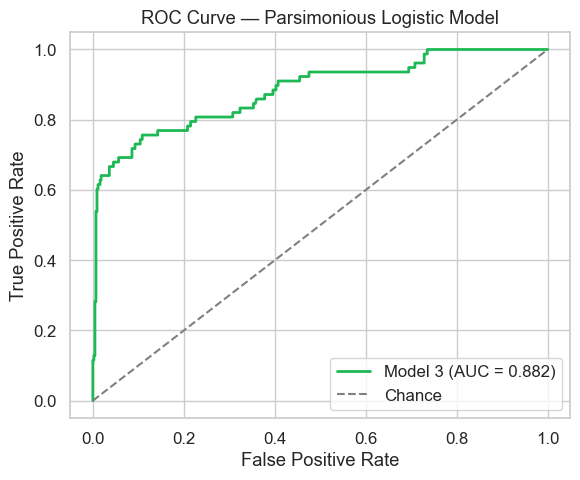

In [ ]:
# ROC curve
fpr, tpr, _ = roc_curve(y, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color=PALETTE[0], linewidth=2, label=f"Model 3 (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Parsimonious Logistic Model")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 10. Hypothesis Verdicts

- **H1a (skip rate $\uparrow \Rightarrow$ bot odds $\uparrow$):** supported if OR for `skip_rate` > 1 and p < .05.
- **H1b (diversity $\downarrow \Rightarrow$ bot odds $\uparrow$):** supported if OR for `diversity_score` < 1 and p < .05.

Directional findings and magnitudes are reported in the paper's Results section.